# 1. Title   


Project 2     
DATA 201 Spring 2026     
Sudipto Bhadra     
Optional: Custom project title      

# 2. Introduction    
Provide a brief description of:    

Dataset source    
Population of interest    
Data collection method (if known)   
Limitations of the data    
Possible bias or ethical concerns   
Include a citation for your dataset.    

## Dataset Source        

The dataset used in this project is Motor Vehicle Collisions – Crashes, obtained from NYC Open Data. It contains records of traffic collisions reported in New York City, including information about crash location, time, contributing factors, and the number of people injured or killed. The dataset is publicly available and is commonly used for transportation safety analysis.         

The data are collected and published by New York City government agencies through the open data portal. These records are based on police reports of motor vehicle crashes, which are compiled and updated regularly to provide information about traffic incidents in the city.           



## Population of Interest        

The population of interest for this analysis is motor vehicle crashes occurring in New York City. Each observation in the dataset represents a single reported collision and includes information about where the crash occurred and how many people were injured.    

The goal of the analysis is to examine whether geographic location variables, such as latitude, longitude, and borough, can help explain or predict the number of injuries that occur in traffic collisions.      



## Data Collection Method     

The data are collected through official crash reports filed by law enforcement officers at the scene of a traffic collision. These reports contain information about the crash location, vehicles involved, and injuries reported at the time of the incident.     

The reports are submitted to the city’s transportation and public safety databases and then published on the open data portal for public access and research use.    



## Limitations of the Data     

One limitation of the dataset is that it does not include many important factors that may influence injury severity, such as vehicle speed, weather conditions, driver behavior, or road conditions. Because of this, the dataset may not fully capture all variables that contribute to crash outcomes.   

Additionally, some fields in the dataset may contain missing values or reporting inconsistencies, which can affect analysis results.     



## Possible Bias or Ethical Concerns     

The dataset may contain reporting bias, since not all crashes are reported to law enforcement. Minor accidents without injuries may sometimes go unreported, which could affect the overall representation of crash severity.     

From an ethical perspective, it is important to use the data responsibly and avoid drawing conclusions about individuals or communities without considering broader social and environmental factors that influence traffic safety.     

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [119]:


df = pd.read_csv('Motor_Vehicle_Collisions_-_Crashes.csv')

df.head()

C:\Users\bhadr\AppData\Local\Temp\ipykernel_21684\1976093417.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Motor_Vehicle_Collisions_-_Crashes.csv')


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


In [121]:
df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2256921 entries, 0 to 2256920
Data columns (total 29 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   BOROUGH                        object 
 3   ZIP CODE                       object 
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   LOCATION                       object 
 7   ON STREET NAME                 object 
 8   CROSS STREET NAME              object 
 9   OFF STREET NAME                object 
 10  NUMBER OF PERSONS INJURED      float64
 11  NUMBER OF PERSONS KILLED       float64
 12  NUMBER OF PEDESTRIANS INJURED  int64  
 13  NUMBER OF PEDESTRIANS KILLED   int64  
 14  NUMBER OF CYCLIST INJURED      int64  
 15  NUMBER OF CYCLIST KILLED       int64  
 16  NUMBER OF MOTORIST INJURED     int64  
 17  NUMBER OF MOTORIST KILLED      int64  
 18  CO

In [125]:
df.describe()

,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,COLLISION_ID
count,2.016199e+06,2.016199e+06,2.256903e+06,2.256890e+06,2.256921e+06,2.256921e+06,2.256921e+06,2.256921e+06,2.256921e+06,2.256921e+06,2.256921e+06
mean,4.057586e+01,-7.365778e+01,3.317143e-01,1.596888e-03,6.052671e-02,7.935590e-04,2.942150e-02,1.276075e-04,2.370070e-01,6.446836e-04,3.291762e+06
std,2.451793e+00,4.545631e+00,7.171951e-01,4.217420e-02,2.517875e-01,2.878152e-02,1.712922e-01,1.133479e-02,6.783716e-01,2.775074e-02,1.511016e+06
min,0.000000e+00,-2.013600e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e+01
25%,4.066725e+01,-7.397450e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.200351e+06
50%,4.072017e+01,-7.392656e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.764776e+06
75%,4.076962e+01,-7.386642e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.329205e+06
max,4.334444e+01,0.000000e+00,4.300000e+01,8.000000e+00,2.700000e+01,6.000000e+00,4.000000e+00,2.000000e+00,4.300000e+01,5.000000e+00,4.893765e+06


In [127]:
df.isnull().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           688388
ZIP CODE                          688671
LATITUDE                          240722
LONGITUDE                         240722
LOCATION                          240722
ON STREET NAME                    495274
CROSS STREET NAME                 864504
OFF STREET NAME                  1854021
NUMBER OF PERSONS INJURED             18
NUMBER OF PERSONS KILLED              31
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       8180
CONTRIBUTING FACTOR VEHICLE 2     366386
CONTRIBUTING FACTOR VEHICLE 3    2093528
CONTRIBUTING FACTOR VEHICLE 4    2219547
CONTRIBUTING FACTOR VEHICLE 5    2246681
COLLISION_ID                           0
VEHICLE TYPE COD

In [129]:
cols = [
    "BOROUGH",
    "LATITUDE",
    "LONGITUDE",
    "NUMBER OF PERSONS INJURED"
]

df = df[cols]



## BOROUGH --> Categorical variable.
## LATITUDE, LONGITUDE --> Quantitative variable
## NUMBER OF PERSONS INJURED --> Target variable.

In [131]:
df = df.dropna()

In [ ]:
## Removing any outliers from the Injury Count.

In [133]:
df = df[df["NUMBER OF PERSONS INJURED"] < 10]

In [135]:
df.head()

,BOROUGH,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED
2,BROOKLYN,40.621790,-73.970024,1.0
9,BROOKLYN,40.667202,-73.866500,0.0
10,BROOKLYN,40.683304,-73.917274,0.0
13,BRONX,40.868160,-73.831480,2.0
14,BROOKLYN,40.671720,-73.897100,0.0


In [137]:
df.shape

(1530470, 4)

# 3. Data Overview   
Describe your dataset:    

Number of rows and columns   
What each row represents   
Table of variables:    
Name   
Type (quantitative/categorical)   
Description    
Include any data cleaning or transformations performed.    

## Dataset Size

The dataset contains many rows and multiple columns. Each row represents one motor vehicle crash reported in New York City. The columns contain information about the crash location and the number of people injured.



## What Each Row Represents

Each row in the dataset represents a single traffic collision event. The row includes details such as where the crash occurred and how many people were injured in that incident. This allows us to analyze patterns in crash severity across different locations.



## Table of Variables
Variable	Type	Description
LATITUDE	Quantitative	Geographic latitude of the crash location
LONGITUDE	Quantitative	Geographic longitude of the crash location
BOROUGH	Categorical	Borough in New York City where the crash occurred
NUMBER OF PERSONS INJURED	Quantitative	Number of people injured in the crash



## Data Cleaning and Transformations

Before analysis, some basic data cleaning was performed. Rows with missing values in the selected variables were removed to ensure the model could be built correctly.

The categorical variable BOROUGH was also converted into dummy variables so it could be used in the regression model. This transformation allows the model to include categorical information in numerical form.

# 4. Data Analysis and Modeling   
This is the main part of your project.    

a. Data Exploration and Visualization    
Create and interpret at least 3 visualizations, such as:    

Histograms   
Scatter plots   
Boxplots   
Bar charts   
Describe patterns, relationships, or interesting observations.   

## Histogram

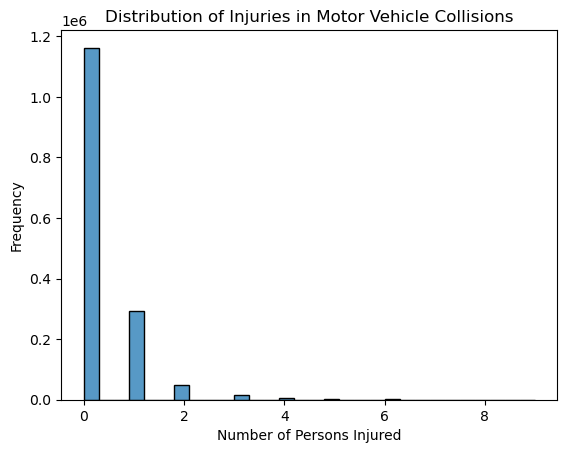

In [139]:
sns.histplot(df["NUMBER OF PERSONS INJURED"], bins=30)

plt.xlabel("Number of Persons Injured")
plt.ylabel("Frequency")
plt.title("Distribution of Injuries in Motor Vehicle Collisions")


plt.savefig("Histo")
plt.show()

### Interpretation


It appears that most crashes result in either 0 or one injured person. Crashes with many injuries are rare hence the distribution is right skewed.

The histogram shows the distribution of the number of persons injured in traffic collisions. Most crashes result in zero or one injury, while crashes with a larger number of injuries are much less common. This indicates that severe accidents happen less frequently compared to minor collisions. The distribution is right-skewed, meaning most values are small with only a few crashes involving many injured people.




## Boxplot

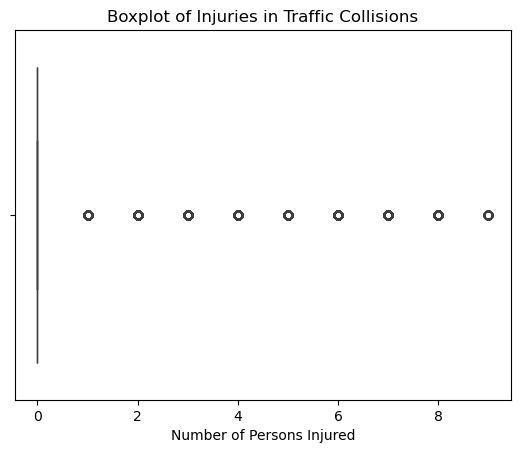

In [141]:
sns.boxplot(x=df["NUMBER OF PERSONS INJURED"])

plt.xlabel("Number of Persons Injured")
plt.title("Boxplot of Injuries in Traffic Collisions")

plt.savefig("box")
plt.show()

### Interpretation

The boxplot shows the spread of the number of persons injured in traffic collisions. Most of the values are concentrated near zero or one injury, indicating that many crashes result in few or no injuries. The plot also shows several outliers, which represent crashes where a larger number of people were injured. This suggests that while most accidents are minor, a small number of crashes result in more severe injuries.


## Barchart

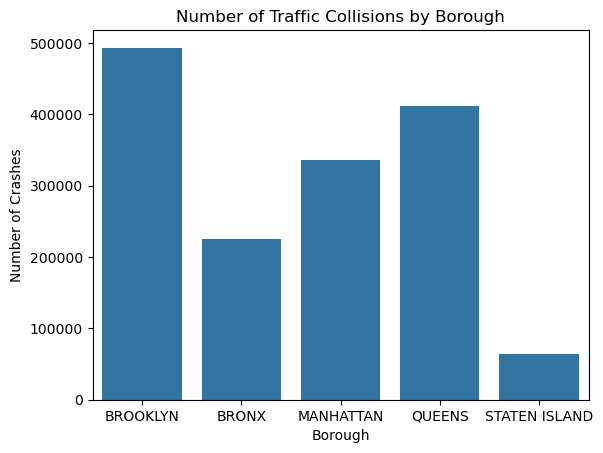

In [143]:
sns.countplot(data=df, x="BOROUGH")

plt.xlabel("Borough")
plt.ylabel("Number of Crashes")
plt.title("Number of Traffic Collisions by Borough")

plt.savefig("Bar")
plt.show()

### Interpretation

Some boroughs experience significantly more collisions than others, likely due to higher population density and traffic volume.

The bar chart shows the number of traffic crashes in each borough. Some boroughs have more crashes than others, which may be related to higher population and traffic levels. Areas with more vehicles and busy roads are likely to experience more collisions. This suggests that location may play a role in where crashes occur.

# b. Train/Test Split     
Split your data into:     

Training set     
Testing set     
Explain your choice (e.g., 80/20 split).     

In [145]:
# predictors
X = df[["LATITUDE", "LONGITUDE"]]

# target variable
y = df["NUMBER OF PERSONS INJURED"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

The dataset was divided into a training set and a testing set using an 80/20 split.
Eighty percent of the data is used to train the regression model, while the remaining twenty percent is used to evaluate model performance.

The dataset was split into 80% training data and 20% testing data. The training data is used to build the regression model, while the testing data is used to evaluate how well the model performs on new, unseen data. This split helps ensure that the model does not simply memorize the training data and can generalize to other observations.

## c. Build a Baseline Model
Build a linear regression model using your selected variables.

Explain:

What variables you included
Why you chose them

### Variables Used

### Response variable (target)
NUMBER OF PERSONS INJURED

### Predictor variables

LATITUDE
LONGITUDE

### Reason for choosing these variables

Latitude and longitude represent the geographic location of crashes. Different areas may experience different traffic patterns, 
population density, and road conditions. These location variables may therefore 
help explain differences in the number of injuries occurring in collisions.

In [147]:
# creating the model
model = LinearRegression()

# training the model
model.fit(X_train, y_train)

LinearRegression()

In [149]:


coeff_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": model.coef_
})

print(coeff_df)

    Variable  Coefficient
0   LATITUDE    -0.001051
1  LONGITUDE     0.000531


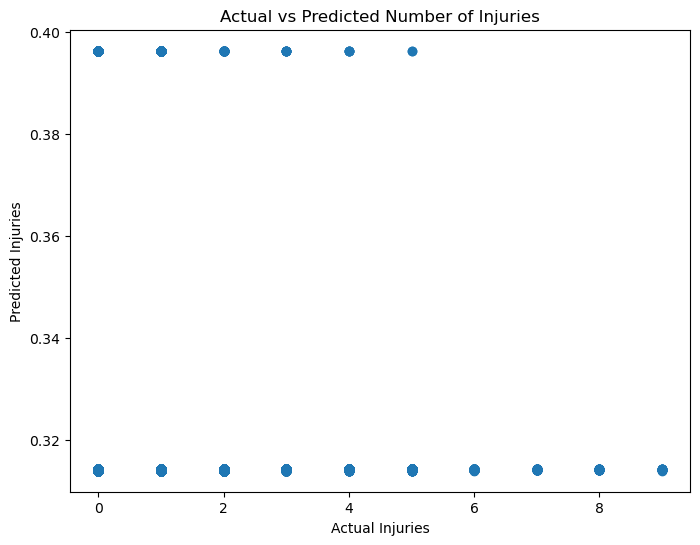

In [151]:

# predictions
y_pred = model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Injuries")
plt.ylabel("Predicted Injuries")
plt.title("Actual vs Predicted Number of Injuries")

plt.savefig("baseline_model_predictions.png")

plt.show()

### Interpretation


The scatter plot compares the actual number of injuries with the predicted values from the baseline linear regression model. 
The predictions appear clustered around a narrow range rather than following the actual injury values closely. 
This suggests that latitude and longitude alone do not strongly explain the number of persons injured in collisions, 
and the baseline model has limited predictive power.

## d. Improve Your Model    
Modify your model using at least ONE of the following:    

Transformation (log, polynomial, etc.)    
Interaction term    
Feature selection (adding/removing variables)    
You must:    

Explain why you made the change   
Support your decision using:     
plots    
patterns in the data     
model results    

To improve the baseline model, we will use feature selection by adding an additional predictor variable:

BOROUGH

The baseline model only used latitude and longitude, which represent geographic coordinates but do not capture differences in 
traffic conditions across areas. 

Adding BOROUGH introduces categorical information about where crashes occur, 
which may influence accident severity due to differences in traffic density, road design, and population.

In [153]:
# Since BOROUGH is categorical, we must convert it into numeric variables using dummy variables.

df_model = pd.get_dummies(df, columns=["BOROUGH"], drop_first=True)

In [161]:
# Improved model predictors and target

X_improved = df_model.drop("NUMBER OF PERSONS INJURED", axis=1)
y_improved = df_model["NUMBER OF PERSONS INJURED"]

X_train_improved, X_test_improved, y_train_improved, y_test_improved = train_test_split(
    X_improved, y_improved, test_size=0.20, random_state=42
)

improved_model = LinearRegression()
improved_model.fit(X_train_improved, y_train_improved)

LinearRegression()

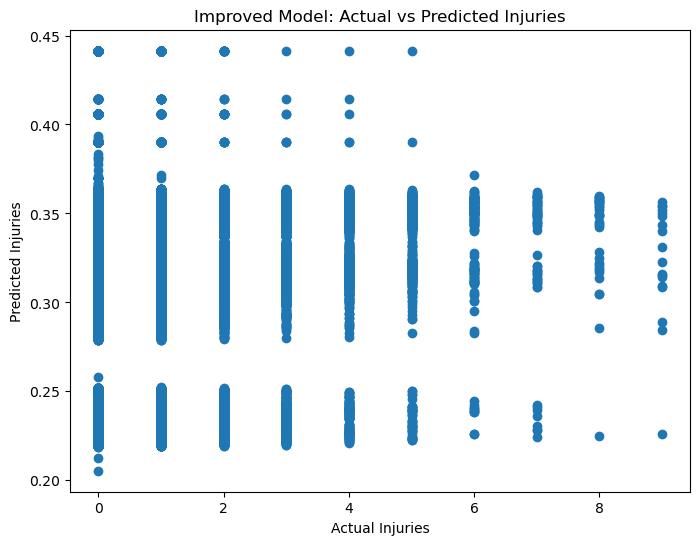

In [163]:
# predictions
y_pred_improved = improved_model.predict(X_test_improved)

plt.figure(figsize=(8,6))

plt.scatter(y_test_improved, y_pred_improved)

plt.xlabel("Actual Injuries")
plt.ylabel("Predicted Injuries")
plt.title("Improved Model: Actual vs Predicted Injuries")

plt.savefig("improved_model_predictions.png")

plt.show()

## Interpretation


The improved model prediction plot shows a slightly wider spread of predicted injury values compared to the baseline model. 
However, predictions still remain within a narrow range and do not closely follow the actual injury values. 
This suggests that although adding the BOROUGH variable introduces additional information, 
the model still struggles to strongly predict injury counts.

## e. Compare Models

Compare your baseline and improved models using appropriate metrics:   

RMSE   
(R^2)    
Clearly explain:    

Which model performs better   
Why   

In [165]:
# baseline predictions
y_pred_baseline = model.predict(X_test)

# improved predictions
y_pred_improved = improved_model.predict(X_test_improved)

# RMSE
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
rmse_improved = np.sqrt(mean_squared_error(y_test_improved, y_pred_improved))

# R2
r2_baseline = r2_score(y_test, y_pred_baseline)
r2_improved = r2_score(y_test_improved, y_pred_improved)

print("Baseline RMSE:", rmse_baseline)
print("Improved RMSE:", rmse_improved)

print("Baseline R2:", r2_baseline)
print("Improved R2:", r2_improved)

Baseline RMSE: 0.668079602593528
Improved RMSE: 0.6663644405293643
Baseline R2: 6.0416883154945644e-05
Improved R2: 0.005188119918342227


## Interpretation


The baseline and improved regression models were compared using RMSE and R². 
The improved model has a slightly lower RMSE (0.6664) compared to the baseline model (0.6681), indicating a small improvement in prediction accuracy. 
Additionally, the R² value increased from approximately 0.00006 to 0.00519, suggesting that the improved model explains 
slightly more variation in the number of injuries.

However, both R² values remain very close to zero, indicating that the predictors used in the models explain only a small portion of the variation 
in injury counts. This suggests that additional variables may be needed to better predict injury outcomes in vehicle collisions.

## f. Interpret Your Final Model   
Explain your regression model in plain language:   

Which variables are important?   
What do the coefficients mean?   
How do predictors affect the response variable?   

The final regression model uses latitude, longitude, and borough information to predict the number of persons injured in a vehicle collision. Among these variables, the borough indicators help capture differences in crash patterns across different areas of the city.

The coefficients in the model represent how changes in the predictor variables affect the predicted number of injuries. For example, a positive coefficient means that as the predictor increases or is present, the predicted number of injuries slightly increases.

Overall, the predictors have only a small effect on the response variable, which suggests that other factors not included in the dataset may play a larger role in determining how many people are injured in a crash.

## g. Predictions    
Use your final model to:    

Make predictions for 3 new data points   
Interpret the results in context   

In [176]:
# Example new crash locations
new_data = pd.DataFrame({
    "LATITUDE": [40.75, 40.68, 40.72],
    "LONGITUDE": [-73.99, -73.95, -73.88],
    "BOROUGH_BROOKLYN": [0, 1, 0],
    "BOROUGH_MANHATTAN": [1, 0, 0],
    "BOROUGH_QUEENS": [0, 0, 1],
    "BOROUGH_STATEN ISLAND": [0, 0, 0]
})

predictions = improved_model.predict(new_data)

print(predictions)

[0.22802056 0.35549618 0.31558823]


### Interpretation

The model predicted the expected number of injuries for three new crash locations. 
The predicted values range between about 0.23 and 0.36, indicating that the model expects fewer than one injury on average for these cases. 
This reflects the pattern in the dataset where most crashes involve very few injuries.


## (Optional) Classification Extension   
You may optionally:    

Build a classification model (e.g., logistic regression)     
Compare it to your regression approach   
If included, you may report:    
   
Accuracy    
ROC-AUC     


In [183]:
df_model["injury_occurred"] = (df_model["NUMBER OF PERSONS INJURED"] > 0).astype(int)

In [189]:
## Training the Logistic Regression Model



from sklearn.linear_model import LogisticRegression

X_class = df_model.drop(["NUMBER OF PERSONS INJURED","injury_occurred"], axis=1)
y_class = df_model["injury_occurred"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.20, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)

LogisticRegression(max_iter=1000)

In [191]:
## Evaluating the model


from sklearn.metrics import accuracy_score, roc_auc_score

y_pred_class = log_model.predict(X_test_c)
y_prob_class = log_model.predict_proba(X_test_c)[:,1]

accuracy = accuracy_score(y_test_c, y_pred_class)
roc_auc = roc_auc_score(y_test_c, y_prob_class)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)


Accuracy: 0.7599201552464275
ROC-AUC: 0.5414999906822678


### Interpretation

A logistic regression model was built to predict whether a crash results in at least one injury. 
The model performance was evaluated using accuracy and ROC-AUC, which measure how well the model distinguishes between crashes with and without injuries. This classification approach provides another way to analyze crash severity compared to the regression model that predicts the number of injuries.



## 5. Conclusions and Recommendations   
Summarize:    

Key findings   
Model performance   
Any challenges or limitations   
Whether your model generalizes well   
Possible next steps or improvements   
If results are not strong or interesting, explain why.   

Key Findings   
The analysis explored how location factors such as latitude, longitude, and borough relate to the number of injuries in vehicle collisions. The results showed that these variables have only a weak relationship with injury counts.

Model Performance     
The improved model performed slightly better than the baseline model, with a marginally lower RMSE and slightly higher R² value. However, the overall predictive power of the model remained limited.

Challenges or Limitations    
One major limitation is that the dataset does not include important factors such as vehicle speed, weather conditions, or driver behavior. These missing variables likely affect the severity of injuries in collisions.

Model Generalization    
Because the model explains only a very small portion of the variation in injuries, its ability to generalize to new crash situations is limited. The predictions therefore should be interpreted with caution.

Possible Next Steps or Improvements   
Future analysis could include additional variables such as time of day, weather conditions, or traffic density. Including more relevant predictors may improve the model's ability to explain injury outcomes.